# The adaptive attacker and the multi-probe defence

Every result so far assumes an attacker who does not know PSBD exists. A security
venue will not accept that assumption, and it should not: a detector that only
works against an oblivious adversary is a detector with a short shelf life.

This notebook covers the 2 halves of that argument.

1. **The adaptive attacker.** An attacker who knows the defence can train against
   it, adding a term to the loss that penalises exactly the signal PSBD reads.
2. **The multi-probe defence.** The defender's reply is to not commit to a single
   probe, so that evading one does not evade the detector.

## The attacker's objective

The attacker wants a working backdoor whose poisoned samples do **not** have
anomalously low PSU. So they add a penalty on the PSU gap:

$$\mathcal{L} = \mathcal{L}_{\text{task}}
+ \lambda \cdot \max\left(0,\;
\overline{\phi_{PSU}}(\text{clean}) - \overline{\phi_{PSU}}(\text{poisoned})\right)$$

The hinge matters. The attacker only pays when the poisoned samples are more
robust than the clean ones, which is the condition PSBD detects. Once the gap
closes there is no gradient pushing it further, so the attacker does not waste
capacity overshooting into a regime that would be anomalous in the other
direction.

| symbol | meaning |
|---|---|
| $\mathcal{L}_{\text{task}}$ | the ordinary poisoned-training loss |
| $\lambda$ | how much the attacker pays for stealth |
| $\overline{\phi_{PSU}}$ | mean PSU over the samples in a batch |

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in psbd resolves the same
# way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import logging

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from psbd.decision import HEADLINE_QUANTILE, detection_report, multi_probe_detection
from psbd.evasion import evasion_penalty, psu_for_batch
from psbd.inference import build_baseline_cache, compute_dropout_pass_probs
from psbd.models import detect_architecture, load_checkpoint
from psbd.operators import build_perturbation
from psbd.positions import plug_dropout, unplug_dropout
from psbd.scores import psu_from_cache, shift_ratio, to_rank
from psbd.splits import build_psbd_loaders_from_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## The penalty, on its own

`evasion_penalty` is small enough to read directly, and its behaviour is worth
seeing before it is buried inside a training run.

In [2]:
demonstration = [
    (
        "poisoned MORE robust than clean, what psbd detects",
        torch.tensor([0.8, 0.7, 0.1, 0.2]),
        torch.tensor([0, 0, 1, 1]),
    ),
    (
        "poisoned and clean equally robust, already evaded",
        torch.tensor([0.5, 0.5, 0.5, 0.5]),
        torch.tensor([0, 0, 1, 1]),
    ),
    (
        "poisoned LESS robust than clean, an inversion",
        torch.tensor([0.1, 0.2, 0.8, 0.7]),
        torch.tensor([0, 0, 1, 1]),
    ),
]
pd.DataFrame(
    [
        {
            "case": label,
            "mean_psu_clean": psu[flags == 0].mean().item(),
            "mean_psu_poisoned": psu[flags == 1].mean().item(),
            "penalty": evasion_penalty(psu, flags.bool()).item(),
        }
        for label, psu, flags in demonstration
    ]
).round(4)

,case,mean_psu_clean,mean_psu_poisoned,penalty
0,"poisoned MORE robust than clean, what psbd det...",0.75,0.15,0.6
1,"poisoned and clean equally robust, already evaded",0.50,0.50,0.0
2,"poisoned LESS robust than clean, an inversion",0.15,0.75,0.0


The third row is the hinge doing its job. An inversion is already undetectable by
a one-sided rule, so the attacker is charged nothing for it.

## What the trained evasive checkpoint achieved

The repository contains checkpoints trained with this objective, marked
`_evade_` in their folder name. Comparing one against its ordinary counterpart is
the actual experiment.

In [3]:
import glob

evasive_folders = sorted(
    os.path.basename(os.path.dirname(path))
    for path in glob.glob("checkpoints/*evade*/args.json")
)
print(f"{len(evasive_folders)} evasive checkpoints on disk")
for folder in evasive_folders[:12]:
    print(" ", folder)

120 evasive checkpoints on disk
  swin_cifar100_adaptive_blend_0_01_evade_l1
  swin_cifar100_adaptive_blend_0_05_evade_l1
  swin_cifar100_adaptive_blend_0_1_evade_l1
  swin_cifar100_badnet_a2a_0_01_evade_l1
  swin_cifar100_badnet_a2a_0_05_evade_l1
  swin_cifar100_badnet_a2a_0_1_evade_l1
  swin_cifar100_badnet_a2o_0_01_evade_l1
  swin_cifar100_badnet_a2o_0_05_evade_l1
  swin_cifar100_badnet_a2o_0_1_evade_l1
  swin_cifar100_blend_0_01_evade_l1
  swin_cifar100_blend_0_05_evade_l1
  swin_cifar100_blend_0_1_evade_l1


In [4]:
import json

PAIRS = [
    ("vit_cifar100_badnet_a2o_0_01", "vit_cifar100_badnet_a2o_0_01_evade_l1"),
    ("swin_cifar100_adaptive_blend_0_01", "swin_cifar100_adaptive_blend_0_01_evade_l1"),
]
PAIRS = [
    (baseline, evasive)
    for baseline, evasive in PAIRS
    if os.path.exists(f"checkpoints/{evasive}/args.json")
]

rows = []
for baseline, evasive in PAIRS:
    for role, folder in (("baseline", baseline), ("evasive", evasive)):
        with open(f"checkpoints/{folder}/args.json") as handle:
            meta = json.load(handle)
        rows.append(
            {
                "pair": baseline,
                "role": role,
                "folder": folder,
                "asr": meta.get("asr"),
                "clean_accuracy": meta.get("clean_accuracy"),
            }
        )
pd.DataFrame(rows).round(4)

,pair,role,folder,asr,clean_accuracy
0,vit_cifar100_badnet_a2o_0_01,baseline,vit_cifar100_badnet_a2o_0_01,1.0000,0.8253
1,vit_cifar100_badnet_a2o_0_01,evasive,vit_cifar100_badnet_a2o_0_01_evade_l1,0.9989,0.8076
2,swin_cifar100_adaptive_blend_0_01,baseline,swin_cifar100_adaptive_blend_0_01,0.4819,0.8618
3,swin_cifar100_adaptive_blend_0_01,evasive,swin_cifar100_adaptive_blend_0_01_evade_l1,0.6670,0.8295


The cost of evasion shows up in `clean_accuracy`. The design document for this
experiment set a success criterion of losing under 2 points of clean accuracy, so
whether that criterion was met is a fact to read off the table rather than a claim
to make.

## Measuring detection on both members of a pair

The same PSBD sweep, run against the ordinary checkpoint and its evasive twin.

In [5]:
PROBES = [
    ("before_attention_norm", "token_mask", 0.5),
    ("before_mlp", "token_mask", 0.5),
    ("after_embedding", "token_mask", 0.5),
]
MAX_SAMPLES = 800
FORWARD_PASSES = 6


def measure_probes(folder):
    checkpoint = f"checkpoints/{folder}/attack_result.pt"
    loaders, manifest = build_psbd_loaders_from_checkpoint(
        checkpoint, max_samples=MAX_SAMPLES
    )
    architecture = detect_architecture(checkpoint)
    model = load_checkpoint(architecture, checkpoint, device)

    baselines = {
        name: build_baseline_cache(model, loader, device, True)
        for name, loader in loaders.items()
    }
    probs = {n: torch.cat([b["probs"] for b in c]) for n, c in baselines.items()}
    labels = {n: torch.cat([b["labels"] for b in c]) for n, c in baselines.items()}

    per_probe = []
    for position, operator, rate in PROBES:
        handles = plug_dropout(
            model,
            architecture,
            (position,),
            {position: build_perturbation(operator)},
            rate,
        )
        try:
            model.train()
            scored = {}
            for name, loader in loaders.items():
                pass_probs, argmax = compute_dropout_pass_probs(
                    model, loader, labels[name], device, FORWARD_PASSES, True, seed=0
                )
                scored[name] = {
                    "psu": psu_from_cache(probs[name], labels[name], pass_probs),
                    "sigma": shift_ratio(labels[name], argmax),
                }
        finally:
            model.eval()
            unplug_dropout(handles)
        per_probe.append(
            {"position": position, "operator": operator, "rate": rate, **scored}
        )

    del model
    torch.cuda.empty_cache() if device.type == "cuda" else None
    return per_probe


measurements = {folder: measure_probes(folder) for pair in PAIRS for folder in pair}
print("measured:", list(measurements))

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


measured: ['vit_cifar100_badnet_a2o_0_01', 'vit_cifar100_badnet_a2o_0_01_evade_l1', 'swin_cifar100_adaptive_blend_0_01', 'swin_cifar100_adaptive_blend_0_01_evade_l1']


In [6]:
single_rows = []
for folder, per_probe in measurements.items():
    for probe in per_probe:
        report = detection_report(
            probe["validation"]["psu"],
            probe["clean"]["psu"],
            probe["backdoor"]["psu"],
            HEADLINE_QUANTILE,
        )
        single_rows.append(
            {
                "folder": folder,
                "probe": f"{probe['position']} + {probe['operator']}",
                "sigma": probe["validation"]["sigma"],
                "auroc": report["auroc"],
                "tpr": report["tpr"],
                "fpr": report["fpr"],
            }
        )
single = pd.DataFrame(single_rows)
single.round(4)

,folder,probe,sigma,auroc,tpr,fpr
0,vit_cifar100_badnet_a2o_0_01,before_attention_norm + token_mask,0.8667,0.9823,1.0000,0.2825
1,vit_cifar100_badnet_a2o_0_01,before_mlp + token_mask,0.9456,0.9702,0.9975,0.2387
2,vit_cifar100_badnet_a2o_0_01,after_embedding + token_mask,0.5154,0.7466,0.5038,0.2775
3,vit_cifar100_badnet_a2o_0_01_evade_l1,before_attention_norm + token_mask,0.7360,0.0231,0.0013,0.2438
4,vit_cifar100_badnet_a2o_0_01_evade_l1,before_mlp + token_mask,0.9004,0.9126,0.9558,0.2550
5,vit_cifar100_badnet_a2o_0_01_evade_l1,after_embedding + token_mask,0.5417,0.5617,0.2109,0.2663
6,swin_cifar100_adaptive_blend_0_01,before_attention_norm + token_mask,0.8656,0.7961,0.7361,0.2188
7,swin_cifar100_adaptive_blend_0_01,before_mlp + token_mask,0.9752,0.8280,0.7727,0.2288
8,swin_cifar100_adaptive_blend_0_01,after_embedding + token_mask,0.7640,0.6880,0.4760,0.2438
9,swin_cifar100_adaptive_blend_0_01_evade_l1,before_attention_norm + token_mask,0.8569,0.8788,0.8914,0.2788


## The multi-probe union

A single probe is a single thing to evade. The union defence scores a sample with
several probes and takes the **best rank across probes**, so a sample only looks
clean if it looks clean to every probe at once.

Ranks rather than raw PSU, because PSU distributions differ in scale between
probes and a raw minimum would be dominated by whichever probe happens to produce
the smallest numbers.

Two thresholding rules, both reading clean validation only:

- **calibrated**, the target quantile of the combined validation score. The
  combined score is already a minimum over probes, so its own quantile absorbs
  however correlated the probes are and lands on target by construction.
- **bonferroni**, the union bound. Conservative, so its achieved FPR sits under
  target and its TPR is understated by the same margin.

In [7]:
union_rows = []
for folder, per_probe in measurements.items():
    for rule in ("calibrated", "bonferroni"):
        result = multi_probe_detection(
            [p["validation"]["psu"] for p in per_probe],
            [p["clean"]["psu"] for p in per_probe],
            [p["backdoor"]["psu"] for p in per_probe],
            target_fpr=HEADLINE_QUANTILE,
            rule=rule,
        )
        by_rule = result.get("by_rule", {}).get(rule, result)
        union_rows.append(
            {
                "folder": folder,
                "rule": rule,
                "auroc": by_rule.get("auroc", result.get("auroc")),
                "tpr": by_rule.get("tpr"),
                "fpr": by_rule.get("fpr"),
            }
        )
union = pd.DataFrame(union_rows)
union.round(4)

,folder,rule,auroc,tpr,fpr
0,vit_cifar100_badnet_a2o_0_01,calibrated,0.9640,0.9987,0.2700
1,vit_cifar100_badnet_a2o_0_01,bonferroni,0.9640,0.9962,0.1963
2,vit_cifar100_badnet_a2o_0_01_evade_l1,calibrated,0.8186,0.7576,0.2663
3,vit_cifar100_badnet_a2o_0_01_evade_l1,bonferroni,0.8186,0.5985,0.1825
4,swin_cifar100_adaptive_blend_0_01,calibrated,0.7772,0.6856,0.2300
5,swin_cifar100_adaptive_blend_0_01,bonferroni,0.7772,0.5808,0.1612
6,swin_cifar100_adaptive_blend_0_01_evade_l1,calibrated,0.8725,0.8258,0.2425
7,swin_cifar100_adaptive_blend_0_01_evade_l1,bonferroni,0.8725,0.7677,0.1637


In [8]:
best_single = single.groupby("folder")["auroc"].max().rename("best_single_probe")
union_calibrated = (
    union[union["rule"] == "calibrated"]
    .set_index("folder")["auroc"]
    .rename("multi_probe_union")
)
comparison = pd.concat([best_single, union_calibrated], axis=1)
comparison["union_minus_best_single"] = (
    comparison["multi_probe_union"] - comparison["best_single_probe"]
)
comparison.round(4)

,best_single_probe,multi_probe_union,union_minus_best_single
folder,,,
swin_cifar100_adaptive_blend_0_01,0.8280,0.7772,-0.0507
swin_cifar100_adaptive_blend_0_01_evade_l1,0.8982,0.8725,-0.0257
vit_cifar100_badnet_a2o_0_01,0.9823,0.9640,-0.0183
vit_cifar100_badnet_a2o_0_01_evade_l1,0.9126,0.8186,-0.0940


The last column is the honest question. The union is only worth its extra cost if
it beats the best single probe, and it has to do so **without** the defender being
told which single probe was best, since knowing that requires the answer.

A union that merely matches the best single probe is still valuable against an
adaptive attacker, because the attacker now has to evade every probe rather than
guess which one the defender chose. That argument is about the threat model, not
about the AUROC, and should be made as such.

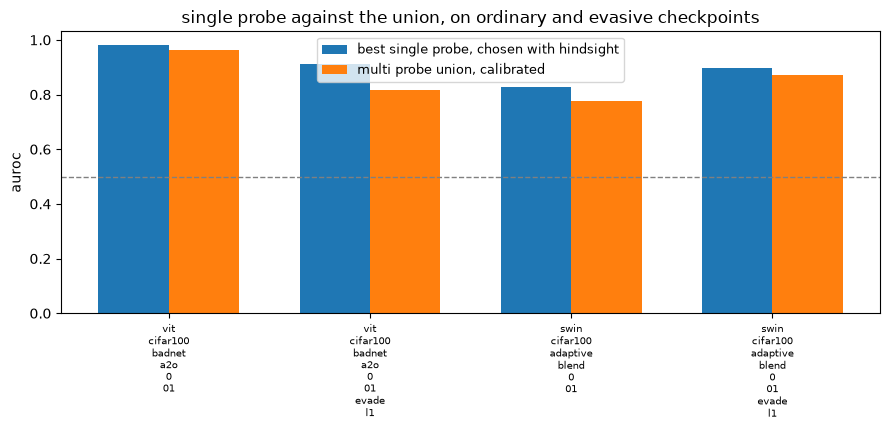

In [9]:
figure, axis = plt.subplots(figsize=(9, 4.4))
folders = list(measurements)
width = 0.35
positions = np.arange(len(folders))

axis.bar(
    positions - width / 2,
    comparison.loc[folders, "best_single_probe"],
    width,
    label="best single probe, chosen with hindsight",
)
axis.bar(
    positions + width / 2,
    comparison.loc[folders, "multi_probe_union"],
    width,
    label="multi probe union, calibrated",
)
axis.axhline(0.5, ls="--", lw=1, c="grey")
axis.set_xticks(positions)
axis.set_xticklabels([f.replace("_", "\n") for f in folders], fontsize=7)
axis.set_ylabel("auroc")
axis.set_title("single probe against the union, on ordinary and evasive checkpoints")
axis.legend(fontsize=9)
figure.tight_layout()
plt.show()

## Reading the result

Compare each evasive checkpoint against its own baseline, not against the other
pair. The question is how much detection the attacker bought away with the
stealth term, and what it cost them in clean accuracy to buy it.

An attacker who drives AUROC to chance while keeping clean accuracy and attack
success intact has broken the defence. An attacker who only reaches chance by
giving up several points of clean accuracy has paid a price a real deployment
would notice, and that price is the defence's actual contribution.